<div style="
    text-align: center; 
    background: linear-gradient(135deg, #0062ff 0%, #00d4ff 100%); 
    font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; 
    color: white; 
    padding: 35px 20px; 
    border-radius: 15px; 
    box-shadow: 0 10px 25px rgba(0, 98, 255, 0.3);
    margin-bottom: 25px;">
    <div style="font-size: 35px; font-weight: 800; letter-spacing: 1.5px; text-transform: uppercase; line-height: 1.2;">
        Trực Quan Hóa Dữ Liệu - Lab 01
    </div>
    <div style="font-size: 16px; font-weight: 500; margin-top: 10px; font-style: italic; opacity: 0.9;">
        "Phân tích thị trường mỹ phẩm nội vs ngoại trên Tiki"
    </div>
    <div style="font-size: 18px; font-weight: 600; margin-top: 15px; border-top: 1px solid rgba(255,255,255,0.4); display: inline-block; padding-top: 10px; letter-spacing: 1px;">
        NHÓM 05 - FIT-HCMUS
    </div>
</div>

<div style="text-align: center; font-size: 40px; font-weight: bold;">
  PHÂN KHÚC GIÁ & CHIẾN LƯỢC KHUYẾN MÃI
</div>

# **1. Thiết lập môi trường và nạp dữ liệu**
## **1.1. Thiết lập môi trường**

In [2]:
# Cài đặt các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style toàn cục cho các biểu đồ
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : False,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
    'figure.dpi'        : 130,
    'savefig.dpi'       : 150,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})

# Bảng màu nhất quán xuyên suốt
C_DOMESTIC = '#2563EB'   # xanh dương — hàng trong nước
C_IMPORT   = '#DC2626'   # đỏ         — hàng ngoài nước
PALETTE    = [C_DOMESTIC, C_IMPORT]
COUNTRY_COLORS = [
    '#EF4444','#F97316','#EAB308','#22C55E','#3B82F6',
    '#8B5CF6','#EC4899','#14B8A6','#F59E0B','#6366F1'
]

print('Các thư viện đã được cài đặt và cấu hình thành công!')

Các thư viện đã được cài đặt và cấu hình thành công!


## **1.2. Nạp dữ liệu**

In [3]:
# 1. Nạp dữ liệu
df = pd.read_csv('../data/tiki_cosmetics_processed.csv')

# 2. Khôi phục thứ tự cho phân khúc giá (để vẽ biểu đồ không bị nhảy lộn xộn)
price_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
df['price_segment'] = pd.Categorical(df['price_segment'], categories=price_order, ordered=True)

# 3. Tập con theo origin_class_corrected (đã hiệu chỉnh ở file preprocessing)
df_vn = df[df['origin_class_corrected'] == 'Trong nước'].copy()
df_nn = df[df['origin_class_corrected'] == 'Ngoài nước'].copy()

# 4. Kiểm tra các chỉ số (ĐÃ FIX LỖI KHOẢNG TRẮNG)
print(f' Tổng sản phẩm : {len(df):,}')
print(f'    Trong nước : {len(df_vn):,} ({len(df_vn)/len(df)*100:.1f}%)')
print(f'    Ngoài nước : {len(df_nn):,} ({len(df_nn)/len(df)*100:.1f}%)')
print(f'Số thương hiệu : {df["brand_name"].nunique():,}')
print(f'   Số danh mục : {df["category"].nunique()}')
print(f'    Khoảng giá : {df["price"].min():,.0f} – {df["price"].max():,.0f} VNĐ')

df.head(5)

 Tổng sản phẩm : 7,179
    Trong nước : 1,915 (26.7%)
    Ngoài nước : 5,264 (73.3%)
Số thương hiệu : 956
   Số danh mục : 30
    Khoảng giá : 10,000 – 18,000,000 VNĐ


,product_id,name,name_clean,brand_name,seller_name,product_type,category,primary_category,origin_class_corrected,origin_corrected,...,estimated_revenue,is_official_store,is_authentic,has_authentic_badge,tiki_verified,availability,availability_label,sold_hidden_flag,has_name_duplicate,is_extreme_outlier
0,277375294,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,2461000,True,1,True,0,1,Còn hàng,False,False,False
1,277375219,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,3069000,True,1,True,0,1,Còn hàng,False,False,False
2,276486487,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Rosette,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,932400,True,1,True,0,1,Còn hàng,False,False,False
3,276396782,Sữa rửa mặt X-Men 100g Detox/Sáng da/Ngừa mụn/...,Sữa rửa mặt X-Men Detox/Sáng da/Ngừa mụn/Kiểm ...,X-Men,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,1116000,True,1,True,0,1,Còn hàng,False,False,False
4,276022717,"Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...","Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...",OXY,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,4582000,True,1,True,0,1,Còn hàng,False,False,False


# **2. Phân tích, trực quan hóa dữ liệu và kết luận**
## **2.1. Mục tiêu 1:** Phân tích mật độ lượt bán theo 5 phân khúc giá để xác định Sweet Spot - phân khúc giá có lượt bán trung bình cao nhất của hàng mỹ phẩm nội địa và ngoại nhập trên Tiki, dựa trên bộ dữ liệu thu thập trong tháng 3/2025.
### **2.1.1. Lí do chọn mục tiêu**
Phân khúc giá là yếu tố định vị sản phẩm cốt lõi quyết định trực tiếp đến tệp khách hàng mục tiêu và cường độ cạnh tranh. Trên Tiki, dữ liệu cho thấy lượt bán phân bổ rất không đồng đều giữa các mức giá: một số phân khúc có median bán gần 0 trong khi phân khúc khác có thể đạt hàng chục lượt/sản phẩm. Việc xác định "Sweet Spot" - phân khúc giá mà sản phẩm bán được nhiều nhất theo trung vị giúp nhà sản xuất nội địa biết nên ưu tiên tập trung nguồn lực vào khoảng giá nào để cạnh tranh hiệu quả nhất với hàng ngoại. Kết quả phân tích cũng làm rõ liệu hàng Việt có đang cạnh tranh đúng "sân chơi" về giá hay đang bị lấn át ngay từ điểm định vị ban đầu, qua đó cung cấp bằng chứng thực nghiệm để đề xuất chiến lược định giá phù hợp.
### **2.1.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể: Phân tích**

**Biểu đồ lựa chọn:**
- **Biểu đồ cột nhóm (Grouped bar chart):** phù hợp nhất để so sánh trực tiếp trung vị lượt bán giữa hàng nội và hàng ngoại trên cùng trục X theo thứ tự phân khúc giá giúp xác định ngay Sweet Spot của từng nhóm bằng cột cao nhất.
- **Biểu đồ hộp (Box plot):** phù hợp để thể hiện toàn bộ hình dạng phân phối lượt bán trong từng phân khúc, bao gồm độ trải, giá trị ngoại lai và độ lệch bổ sung chiều "mật độ" mà biểu đồ cột che khuất.
- **Biểu đồ cột nhóm (Grouped bar chart — Hit Rate):** phù hợp để so sánh tỉ lệ sản phẩm thực sự bán được ít nhất một đơn giữa hai nhóm theo từng phân khúc cho thấy mức độ "sống" thực tế của từng phân khúc thay vì chỉ dựa vào trung vị.

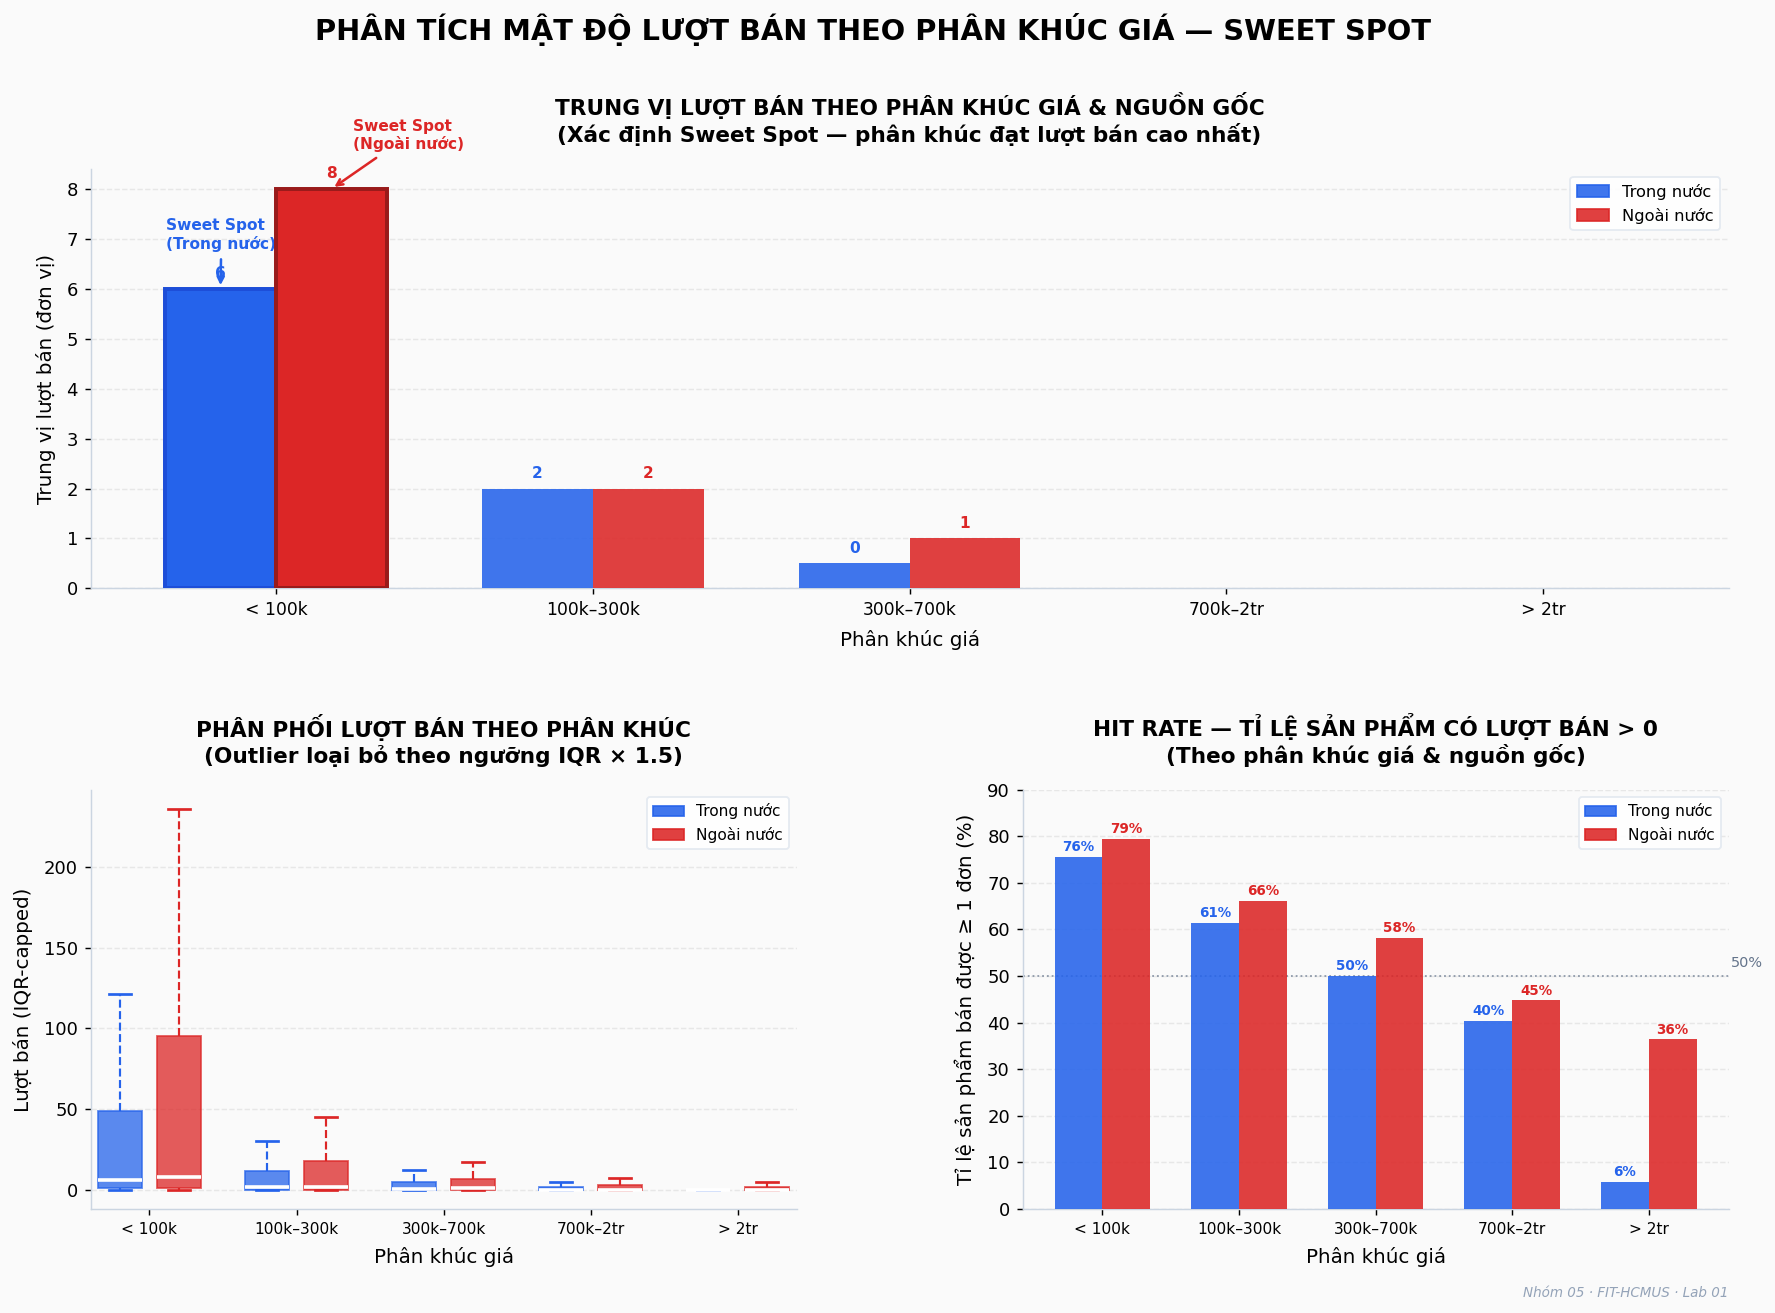

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# MỤC TIÊU 1 · Phân tích mật độ lượt bán theo phân khúc giá — Sweet Spot
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# ── 1. Xử lý outlier: cap sold_count tại Q3 + 1.5×IQR theo từng nhóm ──────
def iqr_cap(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return s.clip(upper=q3 + 1.5 * (q3 - q1))

df['sold_capped'] = (df.groupby(['price_segment', 'origin_class_corrected'],
                                 observed=True)['sold_count']
                       .transform(iqr_cap))

price_labels = ['< 100k', '100k–300k', '300k–700k', '700k–2tr', '> 2tr']

# ── 2. Thống kê cho Biểu đồ 1 (trung vị lượt bán) ─────────────────────────
med = (df.groupby(['price_segment', 'origin_class_corrected'], observed=True)
         ['sold_count'].median().reset_index())
med.columns = ['segment', 'origin', 'median_sold']
med_vn = med[med['origin'] == 'Trong nước']['median_sold'].values
med_nn = med[med['origin'] == 'Ngoài nước']['median_sold'].values

# ── 3. Thống kê cho Biểu đồ 3 (hit rate: % sold > 0) ──────────────────────
def hit_rate(s):
    return (s > 0).mean() * 100

hr = (df.groupby(['price_segment', 'origin_class_corrected'], observed=True)
        ['sold_count'].agg(hit_rate).reset_index())
hr.columns = ['segment', 'origin', 'hit_rate']
hr_vn = hr[hr['origin'] == 'Trong nước']['hit_rate'].values
hr_nn = hr[hr['origin'] == 'Ngoài nước']['hit_rate'].values

# ── 4. Figure layout 2×2 ────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#FAFAFA')

gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.48, wspace=0.32,
                       left=0.07, right=0.97,
                       top=0.88, bottom=0.08)

ax1 = fig.add_subplot(gs[0, :])   # hàng trên — full width
ax2 = fig.add_subplot(gs[1, 0])   # hàng dưới trái
ax3 = fig.add_subplot(gs[1, 1])   # hàng dưới phải

fig.suptitle('PHÂN TÍCH MẬT ĐỘ LƯỢT BÁN THEO PHÂN KHÚC GIÁ — SWEET SPOT',
             fontsize=16, fontweight='bold', y=1)

legend_handles = [
    mpatches.Patch(color=C_DOMESTIC, alpha=0.88, label='Trong nước'),
    mpatches.Patch(color=C_IMPORT,   alpha=0.88, label='Ngoài nước'),
]

# ─────────────────────────────────────────────────────────────────────────────
# BIỂU ĐỒ 1 · Grouped Bar — Trung vị lượt bán theo phân khúc & nguồn gốc
# ─────────────────────────────────────────────────────────────────────────────
x     = np.arange(len(price_order))
width = 0.35

bars_vn = ax1.bar(x - width/2, med_vn, width, color=C_DOMESTIC, alpha=0.88, zorder=3)
bars_nn = ax1.bar(x + width/2, med_nn, width, color=C_IMPORT,   alpha=0.88, zorder=3)

# Viền đậm cho Sweet Spot
sweet_vn_idx = int(np.argmax(med_vn))
sweet_nn_idx = int(np.argmax(med_nn))
ax1.bar(sweet_vn_idx - width/2, med_vn[sweet_vn_idx], width,
        color=C_DOMESTIC, alpha=1.0, zorder=4, edgecolor='#1d4ed8', linewidth=2.2)
ax1.bar(sweet_nn_idx + width/2, med_nn[sweet_nn_idx], width,
        color=C_IMPORT,   alpha=1.0, zorder=4, edgecolor='#991b1b', linewidth=2.2)

# Nhãn giá trị
for bar, c in [(bars_vn, C_DOMESTIC), (bars_nn, C_IMPORT)]:
    for b in bar:
        h = b.get_height()
        if h > 0:
            ax1.text(b.get_x() + b.get_width()/2, h + 0.15, f'{h:.0f}',
                     ha='center', va='bottom', fontsize=8.5, color=c, fontweight='bold')

# Chú thích Sweet Spot
ax1.annotate('Sweet Spot\n(Trong nước)',
             xy=(sweet_vn_idx - width/2, med_vn[sweet_vn_idx]),
             xytext=(-30, 22), textcoords='offset points',
             fontsize=8.5, color=C_DOMESTIC, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=C_DOMESTIC, lw=1.4))
ax1.annotate('Sweet Spot\n(Ngoài nước)',
             xy=(sweet_nn_idx + width/2, med_nn[sweet_nn_idx]),
             xytext=(12, 22), textcoords='offset points',
             fontsize=8.5, color=C_IMPORT, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=C_IMPORT, lw=1.4))

ax1.set_xticks(x);  ax1.set_xticklabels(price_labels, fontsize=9.5)
ax1.set_xlabel('Phân khúc giá', labelpad=6)
ax1.set_ylabel('Trung vị lượt bán (đơn vị)', labelpad=6)
ax1.set_title('TRUNG VỊ LƯỢT BÁN THEO PHÂN KHÚC GIÁ & NGUỒN GỐC\n'
              '(Xác định Sweet Spot — phân khúc đạt lượt bán cao nhất)',
              fontsize=12, fontweight='bold', pad=15)
ax1.set_facecolor('#FAFAFA')
ax1.yaxis.grid(True, alpha=0.25, linestyle='--', zorder=0);  ax1.set_axisbelow(True)
ax1.spines['left'].set_color('#cbd5e1');  ax1.spines['bottom'].set_color('#cbd5e1')
ax1.legend(handles=legend_handles, loc='upper right',
           framealpha=0.9, edgecolor='#e2e8f0', fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# BIỂU ĐỒ 2 · Box Plot (IQR-capped) — Phân phối lượt bán
# ─────────────────────────────────────────────────────────────────────────────
box_data_vn = [df[(df['price_segment'] == seg) &
                   (df['origin_class_corrected'] == 'Trong nước')]['sold_capped'].dropna().values
               for seg in price_order]
box_data_nn = [df[(df['price_segment'] == seg) &
                   (df['origin_class_corrected'] == 'Ngoài nước')]['sold_capped'].dropna().values
               for seg in price_order]

positions_vn = np.arange(len(price_order)) * 2.5
positions_nn = positions_vn + 1.0

for bp_data, positions, color in [(box_data_vn, positions_vn, C_DOMESTIC),
                                   (box_data_nn, positions_nn, C_IMPORT)]:
    ax2.boxplot(bp_data, positions=positions, widths=0.75,
                patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color=color, linewidth=1.2, linestyle='--'),
                capprops=dict(color=color, linewidth=1.5),
                flierprops=dict(marker='o', color=color, alpha=0.25, markersize=2.5),
                boxprops=dict(facecolor=color, alpha=0.75, color=color))

ax2.set_xticks(positions_vn + 0.5);  ax2.set_xticklabels(price_labels, fontsize=8.5)
ax2.set_ylabel('Lượt bán (IQR-capped)', labelpad=6)
ax2.set_xlabel('Phân khúc giá', labelpad=6)
ax2.set_title('PHÂN PHỐI LƯỢT BÁN THEO PHÂN KHÚC\n'
              '(Outlier loại bỏ theo ngưỡng IQR × 1.5)',
              fontsize=12, fontweight='bold', pad=15)
ax2.set_facecolor('#FAFAFA')
ax2.yaxis.grid(True, alpha=0.25, linestyle='--', zorder=0);  ax2.set_axisbelow(True)
ax2.spines['left'].set_color('#cbd5e1');  ax2.spines['bottom'].set_color('#cbd5e1')
ax2.legend(handles=legend_handles, loc='upper right',
           framealpha=0.9, edgecolor='#e2e8f0', fontsize=8.5)

# ─────────────────────────────────────────────────────────────────────────────
# BIỂU ĐỒ 3 · Grouped Bar — Hit Rate (% sản phẩm có lượt bán > 0)
# ─────────────────────────────────────────────────────────────────────────────
bars3_vn = ax3.bar(x - width/2, hr_vn, width, color=C_DOMESTIC, alpha=0.88, zorder=3)
bars3_nn = ax3.bar(x + width/2, hr_nn, width, color=C_IMPORT,   alpha=0.88, zorder=3)

for bar, c in [(bars3_vn, C_DOMESTIC), (bars3_nn, C_IMPORT)]:
    for b in bar:
        h = b.get_height()
        ax3.text(b.get_x() + b.get_width()/2, h + 0.6, f'{h:.0f}%',
                 ha='center', va='bottom', fontsize=7.5, color=c, fontweight='bold')

ax3.axhline(50, color='#64748b', linewidth=1, linestyle=':', alpha=0.7, zorder=2)
ax3.text(4.6, 51.2, '50%', fontsize=8, color='#64748b', va='bottom')
ax3.set_xticks(x);  ax3.set_xticklabels(price_labels, fontsize=8.5)
ax3.set_ylabel('Tỉ lệ sản phẩm bán được ≥ 1 đơn (%)', labelpad=6)
ax3.set_xlabel('Phân khúc giá', labelpad=6)
ax3.set_ylim(0, 90)
ax3.set_title('HIT RATE — TỈ LỆ SẢN PHẨM CÓ LƯỢT BÁN > 0\n'
              '(Theo phân khúc giá & nguồn gốc)',
              fontsize=12, fontweight='bold', pad=15)
ax3.set_facecolor('#FAFAFA')
ax3.yaxis.grid(True, alpha=0.25, linestyle='--', zorder=0);  ax3.set_axisbelow(True)
ax3.spines['left'].set_color('#cbd5e1');  ax3.spines['bottom'].set_color('#cbd5e1')
ax3.legend(handles=legend_handles, loc='upper right',
           framealpha=0.9, edgecolor='#e2e8f0', fontsize=8.5)

fig.text(0.97, 0.01, 'Nhóm 05 · FIT-HCMUS · Lab 01',
         ha='right', va='bottom', fontsize=7.5, color='#94a3b8', style='italic')

plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.show()

### **2.1.3. Nhận xét và kết luận**

**Nhận xét từ biểu đồ:**

**① Trung vị lượt bán theo phân khúc giá & nguồn gốc (biểu đồ 1):**
Cả hàng nội địa lẫn ngoại nhập đều có **Sweet Spot chung tại phân khúc "Dưới 100k"** đây là phân khúc duy nhất mà trung vị lượt bán có giá trị thực sự khác 0 (hàng ngoại: **8 lượt**, hàng nội: **6 lượt**). Từ phân khúc "100k–300k" trở lên, trung vị của cả hai nhóm lần lượt giảm về 2, 0.5/1 và xuống bằng 0 tại hai phân khúc cao nhất cho thấy đại đa số sản phẩm ở mức giá từ 700k trở lên **gần như không bán được**. Đáng chú ý, hàng ngoại có trung bình lượt bán cao hơn hàng nội rất nhiều ở phân khúc "Dưới 100k" (6.039 vs 1.051), phản ánh sự hiện diện của một số ít "best seller" ngoại nhập kéo giá trị trung bình lên cực cao dù trung vị hai bên khá sát nhau.

**② Phân phối lượt bán theo phân khúc (biểu đồ 2):**
Box plot sau khi loại outlier cho thấy phân phối lượt bán **lệch phải mạnh** ở tất cả các phân khúc các hộp gần như nằm sát đáy trục Y, whisker trên mới vươn lên đáng kể. Điều này có nghĩa phần lớn sản phẩm bán rất ít, chỉ một nhóm nhỏ là "hàng chạy" thực sự. Phân khúc "Dưới 100k" có whisker dài nhất ở cả hai nhóm, xác nhận đây là phân khúc có biên độ bán hàng rộng nhất. Ở các phân khúc "700k–2tr" và "Trên 2tr", hộp của hàng nội địa gần như co lại thành một đường thẳng là tín hiệu cho thấy sức mua cực kỳ yếu và phân bố đồng đều ở mức gần 0.

**③ Hit Rate - tỉ lệ sản phẩm có lượt bán > 0 (biểu đồ 3):**
Hit Rate giảm đều theo chiều tăng của giá thể hiện xu hướng nhất quán ở cả hai nhóm. Hàng ngoại luôn có hit rate cao hơn hàng nội ở mọi phân khúc. Đặc biệt tại phân khúc "Trên 2tr", hàng ngoại vẫn giữ được hit rate **36.4%**, trong khi hàng nội chỉ đạt **5.9%** tức là hơn 94% sản phẩm nội địa giá trên 2 triệu **không bán được lấy một đơn**. Ngưỡng 50% hit rate (đường chấm tham chiếu) chỉ đạt được ở hai phân khúc thấp nhất (< 100k và 100k–300k) với hàng nội, còn hàng ngoại vươn tới "300k–700k".

**Kết luận:**
Sweet Spot của thị trường mỹ phẩm Tiki tập trung rõ ràng tại **phân khúc "Dưới 100k"** cho cả hai nhóm nguồn gốc, đây là vùng giá mà sản phẩm vừa bán được nhiều nhất (trung vị cao nhất), vừa có xác suất bán được cao nhất (hit rate ~75–80%). Khi vượt qua ngưỡng 700k, cả hàng nội lẫn hàng ngoại đều rơi vào vùng "tồn kho nhiều hơn bán" với trung vị = 0. Hàm ý chiến lược quan trọng nhất là: **thương hiệu nội địa nên ưu tiên định vị sản phẩm dưới 100k để tối đa hoá lượt bán**, đồng thời thận trọng khi mở rộng lên phân khúc cao cấp vì khoảng cách về hiệu quả bán hàng so với hàng ngoại càng doãng rộng khi giá tăng.

## **2. Mục tiêu 2:** Đo lường hiệu quả giảm giá bằng cách so sánh lượt bán trung bình của hàng Việt và hàng quốc tế ở cùng phân khúc giá khi discount >30% so với ≤30%, từ dữ liệu Tiki tháng 3/2025, nhằm xác định liệu giảm giá sâu có giúp thu hẹp chênh lệch lượt bán không.
### **2.2.1. Lí do chọn mục tiêu**
Giảm giá sâu là công cụ khuyến mãi phổ biến nhất trên các sàn thương mại điện tử, nhưng chi phí thực thi lớn và không phải lúc nào cũng tương xứng với mức tăng trưởng lượt bán. Với hàng nội địa đang có lượt bán thấp hơn hàng ngoại ở hầu hết phân khúc, câu hỏi đặt ra là liệu giảm giá >30% có phải là "đòn bẩy" đủ mạnh để thu hẹp khoảng cách đó không. Nếu giảm giá sâu không tạo ra sự khác biệt đáng kể, các thương hiệu Việt đang lãng phí biên lợi nhuận mà không cải thiện được sức cạnh tranh. Ngược lại, nếu chỉ hàng ngoại mới hưởng lợi từ giảm giá sâu, điều đó phản ánh lợi thế thương hiệu vốn có của họ tức là vấn đề không nằm ở giá mà ở nhận diện thương hiệu. Kết quả phân tích sẽ giúp nhà quản lý có cơ sở dữ liệu thực nghiệm để quyết định có nên tiếp tục đầu tư vào chiến lược giảm giá sâu hay chuyển nguồn lực sang các công cụ marketing khác.
### **2.2.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể: Phân tích**

**Biểu đồ lựa chọn:**
- **Biểu đồ cột nhóm (Grouped bar chart - 4 nhóm):** phù hợp để so sánh đồng thời trung vị lượt bán của 4 tổ hợp (nội/ngoại × ≤30%/>30%) trong từng phân khúc giá thể hiện rõ mức độ tuyệt đối và khoảng cách giữa các nhóm trên cùng một khung nhìn.
- **Biểu đồ đường dốc (Slope chart):** phù hợp để trực quan hóa hướng và độ lớn thay đổi lượt bán khi chuyển từ giảm giá ≤30% sang >30%, đường dốc lên cho thấy discount có hiệu quả, đường dốc xuống cho thấy phản tác dụng, phân biệt rõ phản ứng khác nhau giữa hàng nội và hàng ngoại.
- **Biểu đồ cột nhóm (Grouped bar chart - Tỉ lệ áp dụng):** phù hợp để so sánh mức độ sử dụng chiến lược giảm giá sâu giữa hai nhóm theo từng phân khúc cung cấp bối cảnh quan trọng để lý giải tại sao kết quả lượt bán lại có sự chênh lệch như vậy.

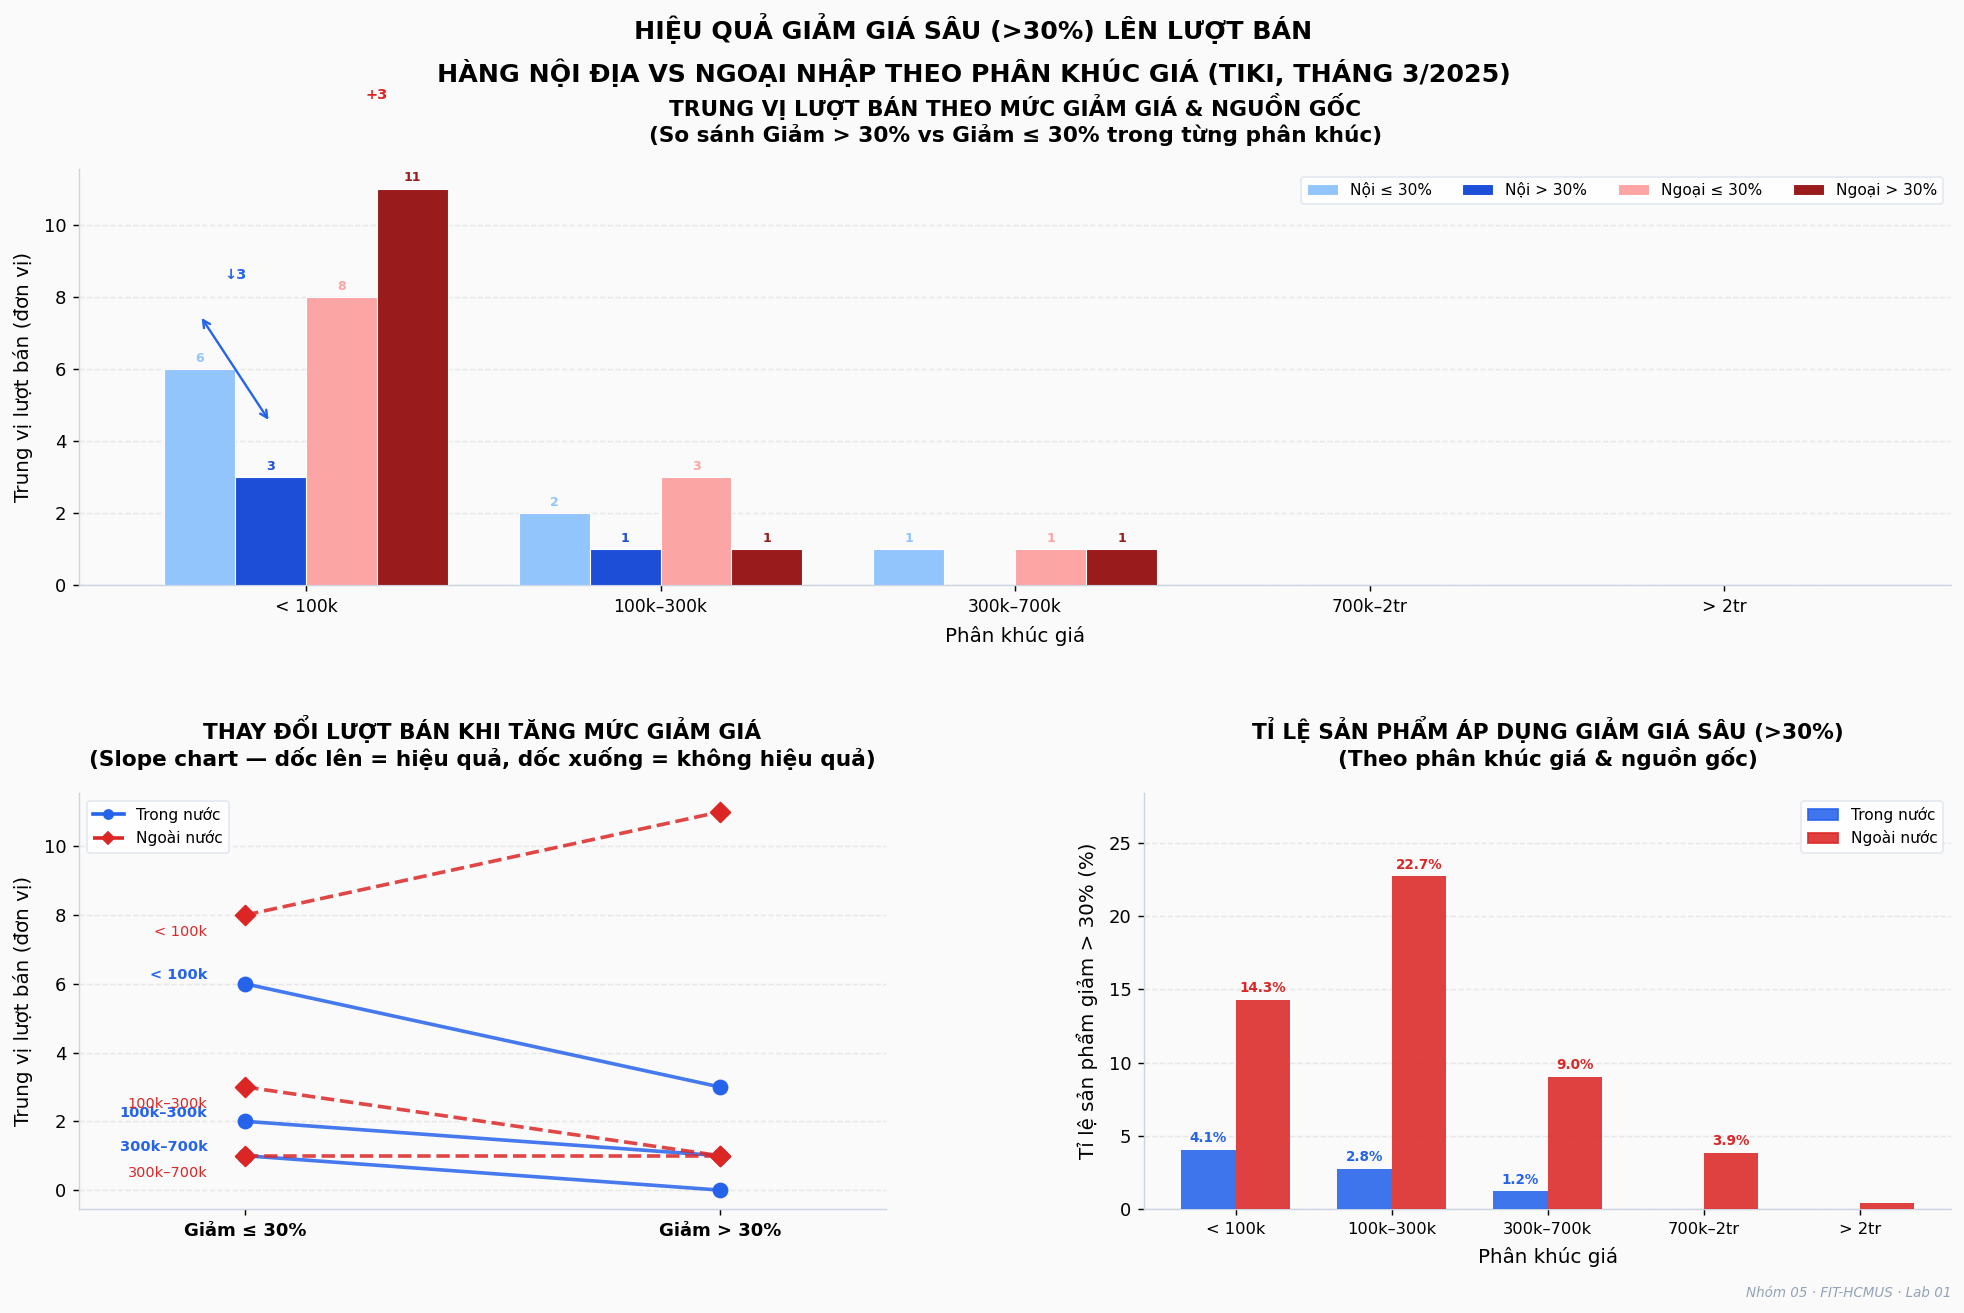

In [6]:
# MỤC TIÊU 2 · Hiệu quả giảm giá sâu lên lượt bán — Nội vs Ngoại
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

#1. Phân nhóm discount
df['disc_bin'] = df['discount_rate'].apply(
    lambda x: 'Giảm > 30%' if x > 30 else 'Giảm ≤ 30%'
)

#2. Median sold theo segment × origin × disc_bin
med = (df.groupby(['price_segment', 'origin_class_corrected', 'disc_bin'], observed=True)
         ['sold_count'].median().reset_index())
med.columns = ['segment', 'origin', 'disc_bin', 'median_sold']

def get_med(origin, disc):
    return (med[(med['origin'] == origin) & (med['disc_bin'] == disc)]
            .set_index('segment').reindex(price_order)['median_sold']
            .fillna(0).values)

vn_lo = get_med('Trong nước', 'Giảm ≤ 30%')
vn_hi = get_med('Trong nước', 'Giảm > 30%')
nn_lo = get_med('Ngoài nước', 'Giảm ≤ 30%')
nn_hi = get_med('Ngoài nước', 'Giảm > 30%')

#3. % sản phẩm discount >30% theo segment × origin
disc_pct = (df.groupby(['price_segment', 'origin_class_corrected'], observed=True)
              .apply(lambda g: (g['discount_rate'] > 30).mean() * 100)
              .reset_index())
disc_pct.columns = ['segment', 'origin', 'pct_deep_disc']
dp_vn = disc_pct[disc_pct['origin'] == 'Trong nước'].set_index('segment').reindex(price_order)['pct_deep_disc'].values
dp_nn = disc_pct[disc_pct['origin'] == 'Ngoài nước'].set_index('segment').reindex(price_order)['pct_deep_disc'].values

#4. Figure layout 2×2
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#FAFAFA')
gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.50, wspace=0.32,
                       left=0.07, right=0.97, top=0.88, bottom=0.08)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

fig.suptitle('HIỆU QUẢ GIẢM GIÁ SÂU (>30%) LÊN LƯỢT BÁN\n'
             'HÀNG NỘI ĐỊA VS NGOẠI NHẬP THEO PHÂN KHÚC GIÁ (TIKI, THÁNG 3/2025)',
             fontsize=14, fontweight='bold', y=1, linespacing=1.6)

# Bảng màu 4 nhóm
C_VN_LO = '#93C5FD'   # xanh nhạt  — nội ≤ 30%
C_VN_HI = '#1D4ED8'   # xanh đậm   — nội > 30%
C_NN_LO = '#FCA5A5'   # đỏ nhạt    — ngoại ≤ 30%
C_NN_HI = '#991B1B'   # đỏ đậm     — ngoại > 30%

# BIỂU ĐỒ 1 · Grouped Bar (4 bar/phân khúc)
x   = np.arange(len(price_order))
w   = 0.20
off = [-1.5, -0.5, 0.5, 1.5]

groups = [
    (vn_lo, C_VN_LO, 'Nội ≤ 30%'),
    (vn_hi, C_VN_HI, 'Nội > 30%'),
    (nn_lo, C_NN_LO, 'Ngoại ≤ 30%'),
    (nn_hi, C_NN_HI, 'Ngoại > 30%'),
]
for (vals, color, label), o in zip(groups, off):
    bars = ax1.bar(x + o*w, vals, w, color=color, zorder=3, label=label,
                   edgecolor='white', linewidth=0.6)
    for b in bars:
        h = b.get_height()
        if h >= 1:
            ax1.text(b.get_x()+b.get_width()/2, h+0.12, f'{h:.0f}',
                     ha='center', va='bottom', fontsize=7, color=color, fontweight='bold')

# Chú thích chênh lệch tại "Dưới 100k"
ax1.annotate('', xy=(x[0]+off[1]*w, vn_hi[0]+1.5), xytext=(x[0]+off[0]*w, vn_lo[0]+1.5),
             arrowprops=dict(arrowstyle='<->', color=C_DOMESTIC, lw=1.3))
ax1.text(x[0]+(-1.0)*w, max(vn_lo[0], vn_hi[0])+2.5, f'↓{vn_lo[0]-vn_hi[0]:.0f}',
         ha='center', fontsize=8, color=C_DOMESTIC, fontweight='bold')
ax1.annotate('', xy=(x[0]+off[3]*w, nn_hi[0]+1.5), xytext=(x[0]+off[2]*w, nn_lo[0]+1.5),
             arrowprops=dict(arrowstyle='<->', color=C_IMPORT, lw=1.3))
ax1.text(x[0]+(1.0)*w, max(nn_lo[0], nn_hi[0])+2.5, f'+{nn_hi[0]-nn_lo[0]:.0f}',
         ha='center', fontsize=8, color=C_IMPORT, fontweight='bold')

ax1.set_xticks(x);  ax1.set_xticklabels(price_labels, fontsize=9.5)
ax1.set_xlabel('Phân khúc giá', labelpad=6)
ax1.set_ylabel('Trung vị lượt bán (đơn vị)', labelpad=6)
ax1.set_title('TRUNG VỊ LƯỢT BÁN THEO MỨC GIẢM GIÁ & NGUỒN GỐC\n'
              '(So sánh Giảm > 30% vs Giảm ≤ 30% trong từng phân khúc)',
              fontsize=12, fontweight='bold', pad=15)
ax1.set_facecolor('#FAFAFA')
ax1.yaxis.grid(True, alpha=0.25, linestyle='--', zorder=0);  ax1.set_axisbelow(True)
ax1.spines['left'].set_color('#cbd5e1');  ax1.spines['bottom'].set_color('#cbd5e1')
ax1.legend(ncol=4, loc='upper right', framealpha=0.9, edgecolor='#e2e8f0', fontsize=8.5)

# BIỂU ĐỒ 2 · Slope Chart — Uplift ≤30% → >30%
show_segs   = price_order[:3]
show_labels = price_labels[:3]

for seg, lbl in zip(show_segs, show_labels):
    idx = price_order.index(seg)
    ax2.plot([0, 1], [vn_lo[idx], vn_hi[idx]], color=C_DOMESTIC, lw=2, alpha=0.85, zorder=3)
    ax2.scatter([0, 1], [vn_lo[idx], vn_hi[idx]], color=C_DOMESTIC, s=60, zorder=4)
    ax2.plot([0, 1], [nn_lo[idx], nn_hi[idx]], color=C_IMPORT,   lw=2, alpha=0.85,
             zorder=3, linestyle='--')
    ax2.scatter([0, 1], [nn_lo[idx], nn_hi[idx]], color=C_IMPORT, s=60, zorder=4, marker='D')
    ax2.text(-0.08, vn_lo[idx]+0.05, lbl, ha='right', va='bottom',
             fontsize=8, color=C_DOMESTIC, fontweight='bold')
    ax2.text(-0.08, nn_lo[idx]-0.3, lbl, ha='right', va='top',
             fontsize=8, color=C_IMPORT)

ax2.set_xlim(-0.35, 1.35)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Giảm ≤ 30%', 'Giảm > 30%'], fontsize=10, fontweight='bold')
ax2.set_ylabel('Trung vị lượt bán (đơn vị)', labelpad=6)
ax2.set_title('THAY ĐỔI LƯỢT BÁN KHI TĂNG MỨC GIẢM GIÁ\n'
              '(Slope chart — dốc lên = hiệu quả, dốc xuống = không hiệu quả)',
              fontsize=12, fontweight='bold', pad=15)
ax2.set_facecolor('#FAFAFA')
ax2.yaxis.grid(True, alpha=0.25, linestyle='--', zorder=0);  ax2.set_axisbelow(True)
ax2.spines['left'].set_color('#cbd5e1');  ax2.spines['bottom'].set_color('#cbd5e1')
ax2.legend(handles=[
    mlines.Line2D([],[],color=C_DOMESTIC, lw=2, marker='o',  markersize=5, label='Trong nước'),
    mlines.Line2D([],[],color=C_IMPORT,   lw=2, marker='D',  markersize=5,
                  linestyle='--', label='Ngoài nước'),
], loc='upper left', framealpha=0.9, edgecolor='#e2e8f0', fontsize=8.5)

# BIỂU ĐỒ 3 · Grouped Bar — Tỉ lệ sản phẩm discount >30%
x3    = np.arange(len(price_order))
w3    = 0.35
b3_vn = ax3.bar(x3 - w3/2, dp_vn, w3, color=C_DOMESTIC, alpha=0.88, zorder=3)
b3_nn = ax3.bar(x3 + w3/2, dp_nn, w3, color=C_IMPORT,   alpha=0.88, zorder=3)

for bar, c in [(b3_vn, C_DOMESTIC), (b3_nn, C_IMPORT)]:
    for b in bar:
        h = b.get_height()
        if h >= 0.5:
            ax3.text(b.get_x()+b.get_width()/2, h+0.3, f'{h:.1f}%',
                     ha='center', va='bottom', fontsize=7.5, color=c, fontweight='bold')

ax3.set_xticks(x3);  ax3.set_xticklabels(price_labels, fontsize=9)
ax3.set_ylabel('Tỉ lệ sản phẩm giảm > 30% (%)', labelpad=6)
ax3.set_xlabel('Phân khúc giá', labelpad=6)
ax3.set_ylim(0, max(dp_vn.max(), dp_nn.max()) * 1.25)
ax3.set_title('TỈ LỆ SẢN PHẨM ÁP DỤNG GIẢM GIÁ SÂU (>30%)\n'
              '(Theo phân khúc giá & nguồn gốc)',
              fontsize=12, fontweight='bold', pad=15)
ax3.set_facecolor('#FAFAFA')
ax3.yaxis.grid(True, alpha=0.25, linestyle='--', zorder=0);  ax3.set_axisbelow(True)
ax3.spines['left'].set_color('#cbd5e1');  ax3.spines['bottom'].set_color('#cbd5e1')
ax3.legend(handles=[
    mpatches.Patch(color=C_DOMESTIC, alpha=0.88, label='Trong nước'),
    mpatches.Patch(color=C_IMPORT,   alpha=0.88, label='Ngoài nước'),
], loc='upper right', framealpha=0.9, edgecolor='#e2e8f0', fontsize=8.5)

fig.text(0.97, 0.01, 'Nhóm 05 · FIT-HCMUS · Lab 01',
         ha='right', va='bottom', fontsize=7.5, color='#94a3b8', style='italic')

plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.show()

### **2.2.3. Nhận xét và kết luận**

**Nhận xét từ biểu đồ:**

**① Trung vị lượt bán theo mức giảm giá & nguồn gốc (biểu đồ 1):**
Kết quả cho thấy giảm giá >30% **không cải thiện lượt bán một cách đồng đều** giữa hai nhóm. Tại phân khúc "Dưới 100k", hàng ngoại hưởng lợi nhẹ từ giảm giá sâu (trung vị tăng từ 8 lên 11 lượt, +3), trong khi hàng nội lại **giảm ngược** (từ 6 xuống 3 lượt, −3). Ở phân khúc "100k–300k", cả hai nhóm đều không được lợi: trung vị hàng ngoại giảm từ 3 xuống 1, hàng nội giảm từ 2 xuống 1. Từ "300k–700k" trở lên, trung vị của tất cả các nhóm đều bằng 0 hoặc 1 cho thấy discount không còn tác dụng phân biệt nào.

**② Thay đổi lượt bán khi tăng mức giảm giá (biểu đồ 2):**
Slope chart làm rõ hướng tác động của discount một cách trực quan nhất. Tại "Dưới 100k", đường hàng ngoại (đỏ đứt) **dốc lên** từ trái sang phải là tín hiệu discount có hiệu quả trong khi đường hàng nội (xanh liền) **dốc xuống**, nghĩa là giảm giá sâu phản tác dụng với hàng Việt ở phân khúc này. Tại "100k–300k" và "300k–700k", cả hai đường đều phẳng hoặc dốc xuống cho thấy discount >30% không tạo ra sự khác biệt ý nghĩa ở các phân khúc giá trung và cao. **Không có phân khúc nào mà hàng nội hưởng lợi rõ ràng từ giảm giá sâu.**

**③ Tỉ lệ sản phẩm áp dụng giảm giá >30%: (biểu đồ 3)**
Hàng ngoại đang dùng công cụ giảm giá sâu nhiều hơn hàng nội ở mọi phân khúc đặc biệt rõ tại "100k–300k" (22.7% hàng ngoại vs 2.8% hàng nội) và "Dưới 100k" (14.3% vs 4.1%). Tổng toàn bộ dataset, có **656 sản phẩm ngoại** áp dụng discount >30%, gấp hơn **15 lần** so với chỉ **42 sản phẩm nội**. Điều này phản ánh chiến lược chủ động của các thương hiệu nước ngoài: họ có biên lợi nhuận đủ dày để giảm giá sâu mà vẫn có lãi, đồng thời dùng discount như một công cụ thu hút khách hàng mới thay vì chỉ để giải phóng hàng tồn.

**Kết luận:**
Giảm giá sâu (>30%) **không phải là đòn bẩy hiệu quả cho hàng nội địa** trên Tiki. Bằng chứng rõ nhất là ở "Dưới 100k", phân khúc mà hàng Việt có lợi thế cạnh tranh nhất và discount >30% lại khiến trung vị lượt bán giảm từ 6 xuống còn 3, trong khi hàng ngoại với cùng mức discount lại tăng từ 8 lên 11. Khoảng cách giữa nội và ngoại khi không discount chỉ là **2 lượt** (8 vs 6), nhưng khi cả hai cùng discount >30%, khoảng cách **nới rộng lên 8 lượt** (11 vs 3). Điều này gợi ý rằng người mua chọn hàng ngoại khi có khuyến mãi tức là discount kích hoạt sự so sánh giá và trong cuộc so sánh đó, thương hiệu ngoại chiếm ưu thế. Hàm ý chiến lược: thay vì đua giảm giá sâu, thương hiệu Việt nên tập trung vào xây dựng nhận diện thương hiệu và chất lượng sản phẩm để tạo lợi thế bền vững hơn là lợi thế giá ngắn hạn.

## **3. Mục tiêu 3:** Tính toán và so sánh doanh thu trung bình trên mỗi sản phẩm (AUR (Average Unit Revenue) = giá × lượt bán) theo từng danh mục mỹ phẩm giữa hàng nội địa và ngoại nhập trên Tiki trong tháng 3/2025, nhằm xác định danh mục nào hàng ngoại đang tạo ra giá trị vượt trội so với hàng nội.
### **2.3.1. Lí do chọn mục tiêu**
Lượt bán cao chưa chắc đồng nghĩa với doanh thu lớn. Ví dụ một sản phẩm giá 2 triệu bán 10 đơn tạo ra giá trị gấp 20 lần sản phẩm giá 100k bán 10 đơn. AUR (Average Unit Revenue = giá × lượt bán) kết hợp cả hai chiều này thành một chỉ số đơn lẻ phản ánh sức tạo ra doanh thu thực tế của từng danh mục. Việc so sánh AUR theo danh mục giúp xác định đâu là "chiến trường" mà hàng ngoại đang không chỉ bán nhiều hơn mà còn thu tiền nhiều hơn đáng kể so với hàng nội đây là thông tin cốt lõi để phân bổ nguồn lực cạnh tranh. Ngược lại, những danh mục hàng nội có AUR ngang bằng hoặc cao hơn chính là lợi thế thực sự cần được bảo vệ và nhân rộng. Phân tích này cũng bổ sung chiều giá trị kinh tế vào bức tranh thị trường vượt ra ngoài việc chỉ đếm lượt bán giúp nhà quản lý đưa ra quyết định đầu tư dựa trên tiềm năng doanh thu thực, không chỉ dựa trên số đơn hàng.
### **2.3.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể: Phân tích, truy vấn**

**Biểu đồ lựa chọn:**
- **Biểu đồ cột ngang phân kỳ (Horizontal diverging bar chart):** phù hợp nhất để hiển thị chiều và độ lớn chênh lệch AUR (ngoại - nội) trên nhiều danh mục, cột sang phải nghĩa là hàng ngoại vượt trội, sang trái là hàng nội thắng, cho phép xếp hạng toàn bộ 27 danh mục bằng một cái nhìn duy nhất.
- **Biểu đồ cột ngang nhóm (Grouped horizontal bar chart):** phù hợp để so sánh AUR tổng hợp giữa hàng nội và ngoại theo 5 nhóm ngành hàng lớn cung cấp bức tranh tổng thể ở cấp độ ngành, bổ sung ngữ cảnh cho biểu đồ danh mục chi tiết bên trên.
- **Biểu đồ phân tán (Scatter plot):** phù hợp để đặt AUR nội và AUR ngoại lên hai trục tọa độ, mỗi điểm là một danh mục, đường y=x làm ranh giới "ngang bằng" giúp phát hiện danh mục có chênh lệch cực đoan và hướng ưu thế của từng nhóm một cách trực quan nhất.

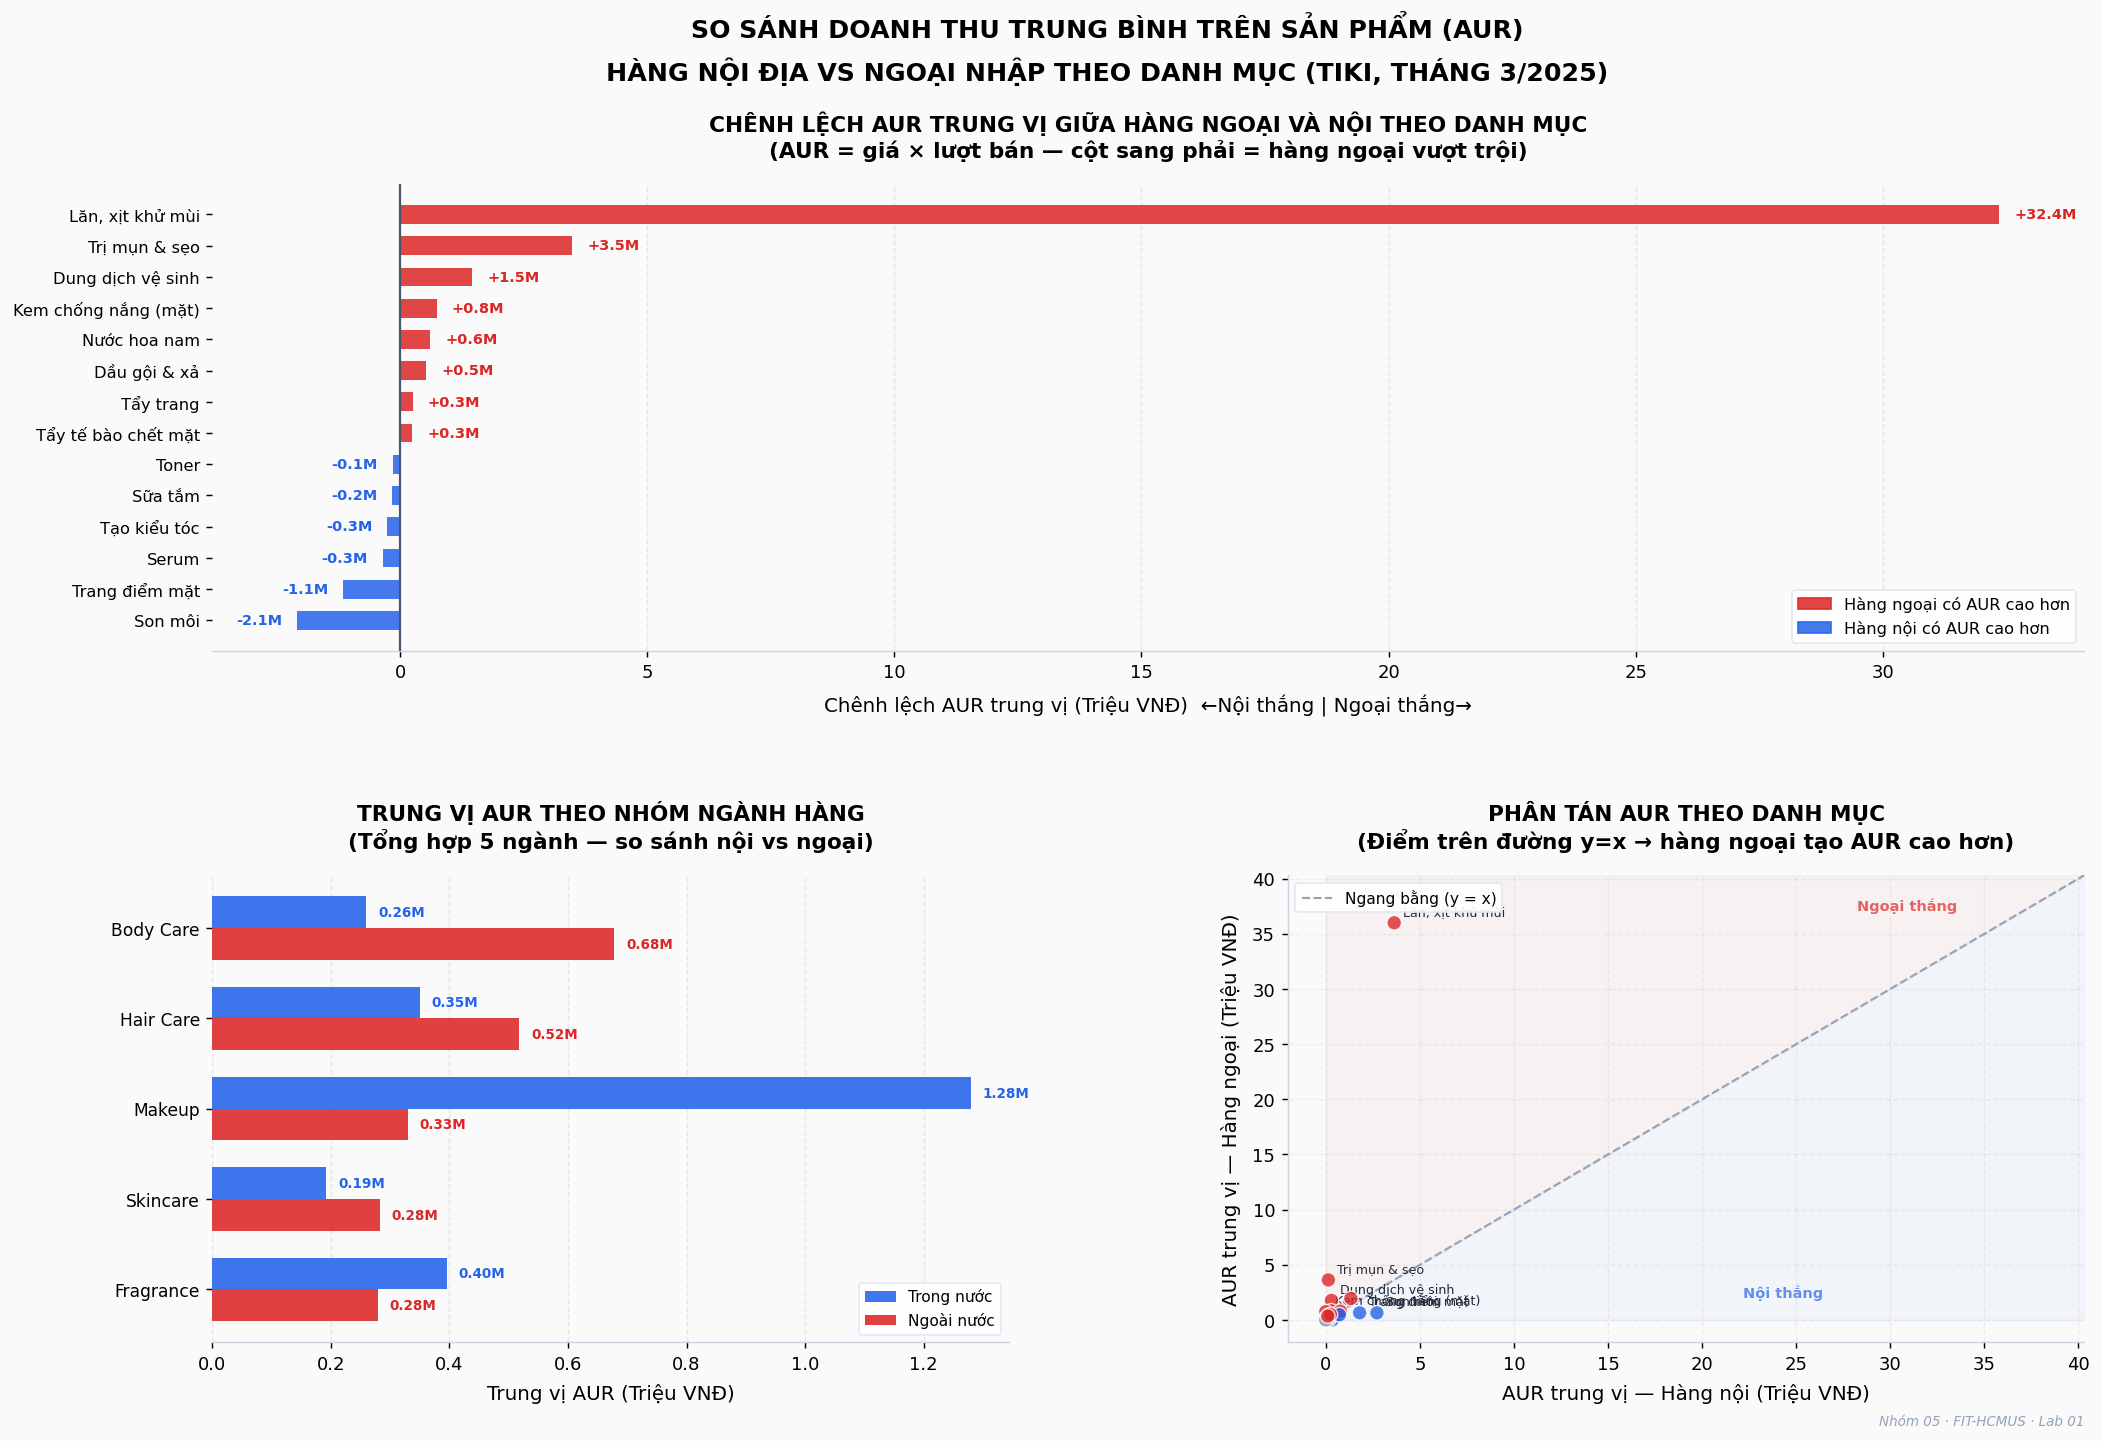

In [8]:
# MỤC TIÊU 3 · So sánh AUR theo danh mục — Nội vs Ngoại
# AUR = estimated_revenue (price × sold_count, đã tính sẵn trong dataset)
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

#1. Chuẩn bị AUR & lọc danh mục hợp lệ (>= 5 SP mỗi nhóm)
df['AUR'] = df['estimated_revenue']

cnt = df.groupby(['category','origin_class_corrected'], observed=True).size().unstack(fill_value=0)
valid_cats = cnt[(cnt.get('Ngoài nước', 0) >= 5) & (cnt.get('Trong nước', 0) >= 5)].index.tolist()

aur = (df[df['category'].isin(valid_cats)]
       .groupby(['category','origin_class_corrected'], observed=True)['AUR']
       .median().unstack(fill_value=0).reset_index())
aur.columns.name = None
aur['gap']    = aur['Ngoài nước'] - aur['Trong nước']
aur['winner'] = aur.apply(
    lambda r: 'Ngoài nước' if r['Ngoài nước'] > r['Trong nước']
              else ('Trong nước' if r['Trong nước'] > r['Ngoài nước'] else 'Ngang bằng'), axis=1)

# Lấy top 8 ngoại thắng + top 8 nội thắng theo gap tuyệt đối
top_pos = aur[aur['gap'] >  0].nlargest(8, 'gap')
top_neg = aur[aur['gap'] <  0].nsmallest(8, 'gap')
show    = pd.concat([top_neg, top_pos]).sort_values('gap')

#2. AUR by product_type
pt = (df.groupby(['product_type','origin_class_corrected'], observed=True)['AUR']
        .median().unstack(fill_value=0).reset_index())
pt.columns.name = None
pt = pt.sort_values('Ngoài nước', ascending=True)

#3. Figure layout 2×2
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#FAFAFA')
gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.48, wspace=0.35,
                       left=0.07, right=0.97, top=0.88, bottom=0.07)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

fig.suptitle('SO SÁNH DOANH THU TRUNG BÌNH TRÊN SẢN PHẨM (AUR)\n'
             'HÀNG NỘI ĐỊA VS NGOẠI NHẬP THEO DANH MỤC (TIKI, THÁNG 3/2025)',
             fontsize=14, fontweight='bold', y=1, linespacing=1.6)

C_TIE = '#94A3B8'

# BIỂU ĐỒ 1 · Horizontal Diverging Bar — Chênh lệch AUR theo danh mục
y_pos  = np.arange(len(show))
gaps   = show['gap'].values / 1e6
cats   = show['category'].values
colors = [C_IMPORT if g > 0 else C_DOMESTIC for g in gaps]

bars = ax1.barh(y_pos, gaps, color=colors, alpha=0.85, zorder=3, height=0.6)
for g, bar, c in zip(gaps, bars, colors):
    xpos = g + (0.3 if g >= 0 else -0.3)
    ha   = 'left' if g >= 0 else 'right'
    sign = '+' if g > 0 else ''
    ax1.text(xpos, bar.get_y() + bar.get_height()/2,
             f'{sign}{g:.1f}M', va='center', ha=ha,
             fontsize=8, color=c, fontweight='bold')

ax1.axvline(0, color='#475569', linewidth=1.2, zorder=4)
ax1.set_yticks(y_pos);  ax1.set_yticklabels(cats, fontsize=9)
ax1.set_xlabel('Chênh lệch AUR trung vị (Triệu VNĐ)  ←Nội thắng | Ngoại thắng→', labelpad=7)
ax1.set_title('CHÊNH LỆCH AUR TRUNG VỊ GIỮA HÀNG NGOẠI VÀ NỘI THEO DANH MỤC\n'
              '(AUR = giá × lượt bán — cột sang phải = hàng ngoại vượt trội)',
              fontsize=12, fontweight='bold', pad=15)
ax1.set_facecolor('#FAFAFA')
ax1.xaxis.grid(True, alpha=0.25, linestyle='--', zorder=0);  ax1.set_axisbelow(True)
ax1.spines['left'].set_color('#cbd5e1');  ax1.spines['bottom'].set_color('#cbd5e1')
ax1.spines['left'].set_visible(False)
ax1.legend(handles=[
    mpatches.Patch(color=C_IMPORT,   alpha=0.85, label='Hàng ngoại có AUR cao hơn'),
    mpatches.Patch(color=C_DOMESTIC, alpha=0.85, label='Hàng nội có AUR cao hơn'),
], loc='lower right', framealpha=0.9, edgecolor='#e2e8f0', fontsize=9)

# BIỂU ĐỒ 2 · Grouped Horizontal Bar — Median AUR theo nhóm ngành hàng
y2   = np.arange(len(pt))
w2   = 0.35
nn_v = pt['Ngoài nước'].values / 1e6
vn_v = pt['Trong nước'].values / 1e6

b_vn = ax2.barh(y2 + w2/2, vn_v, w2, color=C_DOMESTIC, alpha=0.88,
                zorder=3, label='Trong nước')
b_nn = ax2.barh(y2 - w2/2, nn_v, w2, color=C_IMPORT,   alpha=0.88,
                zorder=3, label='Ngoài nước')

for bar, c in [(b_vn, C_DOMESTIC), (b_nn, C_IMPORT)]:
    for b in bar:
        w_val = b.get_width()
        if w_val >= 0.05:
            ax2.text(w_val + 0.02, b.get_y() + b.get_height()/2,
                     f'{w_val:.2f}M', va='center', ha='left',
                     fontsize=7.5, color=c, fontweight='bold')

ax2.set_yticks(y2);  ax2.set_yticklabels(pt['product_type'].values, fontsize=9.5)
ax2.set_xlabel('Trung vị AUR (Triệu VNĐ)', labelpad=6)
ax2.set_title('TRUNG VỊ AUR THEO NHÓM NGÀNH HÀNG\n'
              '(Tổng hợp 5 ngành — so sánh nội vs ngoại)',
              fontsize=12, fontweight='bold', pad=15)
ax2.set_facecolor('#FAFAFA')
ax2.xaxis.grid(True, alpha=0.25, linestyle='--', zorder=0);  ax2.set_axisbelow(True)
ax2.spines['left'].set_color('#cbd5e1');  ax2.spines['bottom'].set_color('#cbd5e1')
ax2.spines['left'].set_visible(False)
ax2.legend(loc='lower right', framealpha=0.9, edgecolor='#e2e8f0', fontsize=8.5)

# BIỂU ĐỒ 3 · Scatter — AUR ngoại vs AUR nội per danh mục
x3    = aur['Trong nước'].values / 1e6
y3    = aur['Ngoài nước'].values / 1e6
c3    = [C_IMPORT if nn > vn else (C_DOMESTIC if vn > nn else C_TIE)
         for vn, nn in zip(x3, y3)]

ax3.scatter(x3, y3, c=c3, s=65, alpha=0.80, zorder=4,
            edgecolors='white', linewidth=0.8)

lim_max = max(x3.max(), y3.max()) * 1.12
ax3.plot([0, lim_max], [0, lim_max], color='#94A3B8', linewidth=1.2,
         linestyle='--', zorder=2, label='Ngang bằng (y = x)')

# Nhãn các điểm nổi bật (gap tuyệt đối lớn nhất)
for idx in aur['gap'].abs().nlargest(6).index:
    row = aur.loc[idx]
    xv, yv = row['Trong nước']/1e6, row['Ngoài nước']/1e6
    ax3.annotate(row['category'], xy=(xv, yv),
                 xytext=(5, 4), textcoords='offset points',
                 fontsize=7, color='#1E293B',
                 arrowprops=dict(arrowstyle='-', color='#CBD5E1', lw=0.8))

# Vùng màu nền
ax3.fill_between([0, lim_max], [0, lim_max], lim_max, alpha=0.04, color=C_IMPORT,   zorder=1)
ax3.fill_between([0, lim_max], 0, [0, lim_max],       alpha=0.04, color=C_DOMESTIC, zorder=1)
ax3.text(lim_max*0.7,  lim_max*0.92, 'Ngoại thắng', fontsize=8,
         color=C_IMPORT,   alpha=0.7, fontweight='bold')
ax3.text(lim_max*0.55, lim_max*0.05, 'Nội thắng',   fontsize=8,
         color=C_DOMESTIC, alpha=0.7, fontweight='bold')

ax3.set_xlim(-lim_max*0.05, lim_max);  ax3.set_ylim(-lim_max*0.05, lim_max)
ax3.set_xlabel('AUR trung vị — Hàng nội (Triệu VNĐ)', labelpad=6)
ax3.set_ylabel('AUR trung vị — Hàng ngoại (Triệu VNĐ)', labelpad=6)
ax3.set_title('PHÂN TÁN AUR THEO DANH MỤC\n'
              '(Điểm trên đường y=x → hàng ngoại tạo AUR cao hơn)',
              fontsize=12, fontweight='bold', pad=15)
ax3.set_facecolor('#FAFAFA')
ax3.grid(True, alpha=0.18, linestyle='--', zorder=0);  ax3.set_axisbelow(True)
ax3.spines['left'].set_color('#cbd5e1');  ax3.spines['bottom'].set_color('#cbd5e1')
ax3.legend(loc='upper left', framealpha=0.9, edgecolor='#e2e8f0', fontsize=8.5)

fig.text(0.97, 0.01, 'Nhóm 05 · FIT-HCMUS · Lab 01',
         ha='right', va='bottom', fontsize=7.5, color='#94a3b8', style='italic')

plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.show()

### **2.3.3. Nhận xét và kết luận**
**① Chênh lệch AUR trung vị giữa hàng ngoại và hàng nội theo danh mục (biểu đồ 1):**
Hàng ngoại áp đảo AUR ở phần lớn danh mục, đặc biệt nổi bật tại **Lăn, xịt khử mùi** (+32.4M VNĐ), **Trị mụn & sẹo** (+3.5M) và **Dung dịch vệ sinh** (+1.5M), đây là những danh mục mà thương hiệu ngoại không chỉ bán giá cao hơn mà còn bán được nhiều hơn đáng kể. Chiều ngược lại, hàng nội tạo AUR cao hơn ở **Son môi** (−2.1M), **Serum** và **Toner** phản ánh thực tế rằng các thương hiệu son môi Việt (như Cocoon, Emmié) đang chiếm lĩnh phân khúc đại trà với lượt bán lớn. Đáng chú ý, chênh lệch bên ngoại thắng lớn hơn nhiều lần so với bên nội thắng cho thấy khi hàng ngoại đã chiếm ưu thế AUR, mức chênh lệch rất cách biệt.

**② Trung vị AUR theo nhóm ngành hàng (biểu đồ 2):**
Nhìn ở cấp độ ngành, **Makeup** là ngành duy nhất hàng nội tạo AUR cao hơn hàng ngoại (1.28M vs 0.33M) chênh lệch gần 4 lần nhờ các thương hiệu son môi Việt bán chạy với giá trung bình cao hơn hàng ngoại ở phân khúc này. **Fragrance** cũng nghiêng về hàng nội (0.40M vs 0.28M). Ngược lại, **Body Care** là ngành hàng ngoại vượt trội nhất về AUR (0.68M vs 0.26M), tiếp theo là **Hair Care** (0.52M vs 0.35M). **Skincare** là ngành có nhiều danh mục nhất gần ngang nhau nhưng hàng ngoại vẫn nhỉnh hơn (0.28M vs 0.19M).

**③ Phân tán AUR theo danh mục (biểu đồ 3):**
Phần lớn các điểm nằm **phía trên đường y=x** xác nhận xu hướng hàng ngoại vượt trội AUR là phổ biến, không phải ngoại lệ. Điểm "Lăn, xịt khử mùi" là outlier cực đoan nằm rất xa đường tham chiếu về phía trên. Các điểm nằm dưới đường (hàng nội thắng) đều tập trung quanh gốc tọa độ tức là AUR tuyệt đối của cả hai nhóm đều thấp, không có danh mục nào hàng nội tạo ra AUR vượt trội ở mức giá trị lớn. Cụm điểm trên đường y=x cho thấy với những danh mục hàng ngoại chiếm ưu thế, mức AUR của họ cao hơn rõ rệt và phân tán rộng hơn.

**Kết luận:**
Hàng ngoại nhập đang tạo ra AUR vượt trội ở đa số danh mục mỹ phẩm trên Tiki, với khoảng cách lớn nhất tại **Body Care** và nhóm chăm sóc cá nhân (Lăn khử mùi, Dung dịch vệ sinh). **Makeup là lãnh địa duy nhất** hàng nội đang thực sự tạo ra giá trị kinh tế lớn hơn — đây là lợi thế chiến lược cần được bảo vệ và phát triển. Hàm ý quan trọng: thay vì cố cạnh tranh dàn trải, thương hiệu Việt nên **tập trung vào Makeup và Fragrance**, hai ngành có nền tảng AUR tốt đồng thời xây dựng thương hiệu mạnh hơn trong Skincare trước khi đối đầu trực tiếp với hàng ngoại ở các danh mục Body Care và Hair Care nơi khoảng cách AUR đang rất lớn.